# Taller Deep Learning

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf

warnings.simplefilter(action="ignore", category=FutureWarning)

## 1. Lectura y preprocesado de datos

Leemos los datos de los precios de cierre de las 23 acciones desde 1945. Vemos que solo hay datos desde 1962, así que tendremos datos desde ese mismo año.

In [2]:
# Leemos los datos de los precios de cierre de las acciones desde 1945 hasta la fecha actual
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']
precios_close.head()

[*********************100%***********************]  23 of 23 completed


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462332,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830128,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892468,0.194749,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606347,0.237781,0.090291
1962-01-05,0.859896,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824461,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602781,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295456,0.057821,0.373051,0.235978,0.178021,0.587311,...,0.807461,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592079,0.229766,0.088095


Observamos que no hay problemas de valores nulos

In [7]:
precios_close.isna().sum()

Ticker
AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0
dtype: int64

Finalmente calculamos los retornos de las acciones durante todo el periodo.

In [3]:
# Calculamos los retornos logarítmicos de los precios de cierre
returns = np.log(precios_close).diff().dropna()
returns.head()

Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019802,0.009694,-0.009820,-0.002260,0.013332,-0.008265,0.000000,0.032924,-0.010085,...,-0.013747,-0.015670,-0.022532,0.020791,0.007491,-0.018518,-0.042802,-0.002911,-0.010989,0.014743
1962-01-04,-0.014706,-0.009851,0.025398,0.000000,-0.009091,0.000000,-0.008333,-0.003091,0.004041,-0.011894,...,-0.003466,-0.010579,0.007570,-0.004124,0.000000,0.006985,-0.010255,-0.008785,-0.016714,0.002435
1962-01-05,-0.022473,-0.020001,0.009361,-0.024419,-0.025435,0.003308,-0.021142,-0.021910,0.004024,-0.025977,...,0.010363,-0.016089,-0.022875,-0.025106,-0.026466,0.011534,-0.034462,-0.005899,-0.007047,-0.022140
1962-01-08,-0.007604,0.002522,0.006192,-0.011299,-0.004695,-0.003308,0.002133,0.004736,0.015937,-0.001755,...,-0.020834,-0.016348,-0.010335,-0.004246,-0.005765,-0.006905,0.003043,-0.017912,-0.027242,-0.002492
1962-01-09,-0.007664,0.002516,0.009216,0.000000,0.014020,0.019677,0.002131,-0.001575,0.003945,0.005259,...,-0.014134,0.010930,0.018017,-0.021506,0.000000,-0.018647,0.004550,-0.024391,-0.001455,-0.002496


La función `create_time_series_data` divide los datos en ventanas de entrada y salida. 

- Las dimensiones de los datos predictores es $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $retornos$ $(ventana$ $de$ $entrada),$ $número$ $de$ $activos)$. Es decir, tenemos tantas particiones como $número$ $de$ $datos$ - $ventana$ $de$ $entrada$ - $ventana$ $de$ $salida + 1$. Cada partición tiene los $ventana$ $de$ $entrada$ retornos. En la primera partición, el primer retorno es el primer retorno de la serie, en la segunda es el segundo retorno y así se van corriendo los retornos sucesivamente. Por último, se aplica todo esto para cada uno de los 23 activos.

- Las dimensiones de los datos a predecir son $(Número$ $de$ $observaciones,$ $Número$ $de$ $activos)$. Tenemos tantos valores a predecir como $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $activos)$. Se consigue reducir la dimensión $Número$ $de$ $retornos$ $(ventana$ $de$ $salida)$ porque sobre esos retornos se calcula la media. Es decir, los valores a predecir son realmente la media de los retornos de la ventana de salida. La ventana de salida está compuesta por los N siguientes retornos que siguen a los retornos que se encuentran en la ventana de entrada. 

Por lo tanto, no hay saltos entre los datos de entrada y salida de los modelos. Lopez de Prado lo recomienda pero en este caso no se utlizará.

In [4]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

In [5]:
# Definir los tamaños de ventana
input_window_size = 10  # Por ejemplo, 10 días de retornos como entrada
output_window_size = 5 # Por ejemplo, el promedio del siguiente día como salida

# Generar series temporales para el conjunto de entrenamiento
X, y = create_time_series_data(returns, input_window_size, output_window_size)


In [14]:
print(returns.shape)
print(X.shape)
print(y.shape)

(16190, 23)
(16176, 10, 23)
(16176, 23)


In [6]:
for i in range(5):
    j = i+10
    print(f"Media de los retornos: {returns.iloc[j:j+5,0].mean()}")
    print(f"Salida y[{i}]: {y[i,0]}\n")

Media de los retornos: 0.0
Salida y[0]: 0.0

Media de los retornos: 0.0
Salida y[1]: 0.0

Media de los retornos: -0.0015152166835171621
Salida y[2]: -0.0015152166835171621

Media de los retornos: -0.004194634495376243
Salida y[3]: -0.004194634495376243

Media de los retornos: -0.003451670283694641
Salida y[4]: -0.003451670283694641



Dividimos los datos en train (90%) y test (10%). Posteriormente, cuando se entrenen modelos de Deep Learning habrá que volver a dividir los datos train en validación. Incluimos la semilla 42 y el parámetro suffle que nos asegurá que los datos train siempre son anteriores a los test. De otro modo, veríamos el futuro y el modelo no tendría sentido.

In [8]:
from sklearn.model_selection import train_test_split

# Set a random seed for reproducibility
RANDOM_SEED = 42

# Split the time series sequences X and y into training and testing sets (90% train, 10% test)
# shuffle=False is crucial for time series data to maintain chronological order
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X, y, test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (14558, 10, 23)
Shape of y_train_seq: (14558, 23)
Shape of X_test_seq: (1618, 10, 23)
Shape of y_test_seq: (1618, 23)


Estandarizamos los datos con `Standard Scaler`

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [9]:
# 1. Reshape a 2D: (Muestras * Días, Activos)
X_train_reshaped = X_train_seq.reshape(-1, 23)

# 2. Fit y Transform sobre el entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)

# 3. Volver a la forma original 3D
X_train_seq_final = X_train_scaled.reshape(X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2])

# 4. Para el Test: SOLO TRANSFORM (usando el scaler de train)
X_test_reshaped = X_test_seq.reshape(-1, 23)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test_seq_final = X_test_scaled.reshape(X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2])

Demostración de como es la partición. Sigue la distribución temporal de los datos.

In [49]:
print(f"Último dato X de train:\n {X[14557,:,0]}")
print(f"Último dato de X_train_seq:\n {X_train_seq[-1,:,0]}")
print(f"\n")
print(f"Primer dato de X test:\n {X[14558,:,0]}")
print(f"Primer dato de X_test_seq:\n {X_test_seq[0,:,0]}")
print(f"\n")
print(f"Último dato y de train y primer dato de y test: {y[14557:14559,0]}")
print(f"Último dato de y_train_seq y primer dato de y_test_seq: {y_train_seq[-1,0]} y {y_test_seq[0,0]}")

Último dato X de train:
 [ 0.0030771  -0.00883277 -0.00815597 -0.01520121  0.00632581 -0.02148249
 -0.00302683 -0.00337362 -0.00304597  0.01525009]
Último dato de X_train_seq:
 [ 0.0030771  -0.00883277 -0.00815597 -0.01520121  0.00632581 -0.02148249
 -0.00302683 -0.00337362 -0.00304597  0.01525009]


Primer dato de X test:
 [-0.00883277 -0.00815597 -0.01520121  0.00632581 -0.02148249 -0.00302683
 -0.00337362 -0.00304597  0.01525009 -0.00289752]
Primer dato de X_test_seq:
 [-0.00883277 -0.00815597 -0.01520121  0.00632581 -0.02148249 -0.00302683
 -0.00337362 -0.00304597  0.01525009 -0.00289752]


Último dato y de train y primer dato de y test: [0.00352978 0.00325463]
Último dato de y_train_seq y primer dato de y_test_seq: 0.0035297847470461717 y 0.0032546315520066925


## 2. Establecimiento de los modelos baselines

Los baselines son modelos simples que usan modelos como la regresión lineal y que sirven para valorar la calidad de los modelos de Deep Learning que diseñemos.

En este caso usaremos la estrategia Buy & Hold y la regresión lineal.

In [21]:
#Obtenemos una partición de los datos de entrenamiento en train y val
X_train_seq2, X_val_seq, y_train_seq2, y_val_seq = train_test_split(X_train_seq, y_train_seq, test_size=0.25, shuffle=False, random_state=RANDOM_SEED)

# Mostramos las dimensiones de cada una de las particiones (train, val y test)
print(f"Shape of X_train_seq: {X_train_seq2.shape}")
print(f"Shape of y_train_seq: {y_train_seq2.shape}")
print(f"Shape of X_val_seq: {X_val_seq.shape}")
print(f"Shape of y_val_seq: {y_val_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (10918, 10, 23)
Shape of y_train_seq: (10918, 23)
Shape of X_val_seq: (3640, 10, 23)
Shape of y_val_seq: (3640, 23)
Shape of X_test_seq: (1618, 10, 23)
Shape of y_test_seq: (1618, 23)


In [22]:
num_samples_train = X_train_seq2.shape[0]
num_samples_val = X_val_seq.shape[0]
num_samples_test = X_test_seq.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat = X_train_seq2.reshape(num_samples_train, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat = X_val_seq.reshape(num_samples_val, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat = X_test_seq.reshape(num_samples_test, -1)

print(f"Shape of X_train_flat: {X_train_flat.shape}")
print(f"Shape of X_valn_flat: {X_val_flat.shape}")
print(f"Shape of X_test_flat: {X_test_flat.shape}")

Shape of X_train_flat: (10918, 230)
Shape of X_valn_flat: (3640, 230)
Shape of X_test_flat: (1618, 230)


Entrenamos un modelo de regresión lineal con los datos que disponemos en las tres particiones. Este modelo será el que usaremos como baseline.

- **MAE Train**: 0.0055
- **MAE Val**: 0.0047
- **MAE Test**: 0.0057

In [23]:
from sklearn.linear_model import LinearRegression

# Inicializar el modelo de regresión lineal
linear_model = LinearRegression()

# Entrenar el modelo con los datos aplanados
linear_model.fit(X_train_flat, y_train_seq2)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_tr = linear_model.predict(X_train_flat)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_val = linear_model.predict(X_val_flat)

# Realizar predicciones en el conjunto de prueba aplanado
y_pred_linear_ts = linear_model.predict(X_test_flat)

print(f"MAE en entrenamiento: {np.mean(np.abs(y_pred_linear_tr-y_train_seq2))}")
print(f"MAE en validación: {np.mean(np.abs(y_pred_linear_val-y_val_seq))}")
print(f"MAE en prueba: {np.mean(np.abs(y_pred_linear_ts-y_test_seq))}")

MAE en entrenamiento: 0.005507565449342765
MAE en validación: 0.004713288241936832
MAE en prueba: 0.005715568520585919


Entremamos un modelo de regresión lineal para cada combinación de ventanas de entrada y salida. Buscamos tener algo así al entrenar los modelos de Deep Learning.

In [18]:
# Define input and output window sizes
input_window_sizes = [5, 10, 30, 90]
output_window_sizes = [1, 5, 30, 90]

# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(input_window_sizes), len(output_window_sizes)))
mae_val_matrix = np.zeros((len(input_window_sizes), len(output_window_sizes)))
mae_test_matrix = np.zeros((len(input_window_sizes), len(output_window_sizes)))

# Loop through all combinations of window sizes
for i, input_ws in enumerate(input_window_sizes):
    for j, output_ws in enumerate(output_window_sizes):
        print(f"Processing Input Window Size: {input_ws}, Output Window Size: {output_ws}")

        # 1. Generate time series data
        X_current, y_current = create_time_series_data(returns, input_ws, output_ws)

        if X_current.size == 0 or y_current.size == 0:
            print(f"Skipping: Not enough data for input_ws={input_ws}, output_ws={output_ws}")
            mae_train_matrix[i][j] = np.nan
            mae_test_matrix[i][j] = np.nan
            continue

        # 2. Split data into training and testing sets
        X_train_seq_curr, X_test_seq_curr, y_train_seq_curr, y_test_seq_curr = train_test_split(
            X_current, y_current, test_size=0.1, shuffle=False, random_state=RANDOM_SEED
        )

        X_train_seq_curr, X_val_seq_curr, y_train_seq_curr, y_val_seq_curr = train_test_split(
              X_train_seq_curr, y_train_seq_curr, test_size=0.05, shuffle=False, random_state=RANDOM_SEED
          )

        # 3. Flatten X data for linear regression
        num_samples_train_curr = X_train_seq_curr.shape[0]
        num_samples_val_curr = X_val_seq_curr.shape[0]
        num_samples_test_curr = X_test_seq_curr.shape[0]

        X_train_flat_curr = X_train_seq_curr.reshape(num_samples_train_curr, -1)
        X_val_flat_curr = X_val_seq_curr.reshape(num_samples_val_curr, -1)
        X_test_flat_curr = X_test_seq_curr.reshape(num_samples_test_curr, -1)

        # 4. Initialize and train Linear Regression model
        linear_model_curr = LinearRegression()
        linear_model_curr.fit(X_train_flat_curr, y_train_seq_curr)

        # 5. Make predictions
        y_pred_linear_tr_curr = linear_model_curr.predict(X_train_flat_curr)
        y_pred_linear_val_curr = linear_model_curr.predict(X_val_flat_curr)
        y_pred_linear_ts_curr = linear_model_curr.predict(X_test_flat_curr)

        # 6. Calculate Mean Absolute Error (MAE)
        mae_train = np.mean(np.abs(y_pred_linear_tr_curr - y_train_seq_curr))
        mae_val = np.mean(np.abs(y_pred_linear_val_curr - y_val_seq_curr))
        mae_test = np.mean(np.abs(y_pred_linear_ts_curr - y_test_seq_curr))

        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_train
        mae_val_matrix[i][j] = mae_val
        mae_test_matrix[i][j] = mae_test

Processing Input Window Size: 5, Output Window Size: 1
Processing Input Window Size: 5, Output Window Size: 5
Processing Input Window Size: 5, Output Window Size: 30
Processing Input Window Size: 5, Output Window Size: 90
Processing Input Window Size: 10, Output Window Size: 1
Processing Input Window Size: 10, Output Window Size: 5
Processing Input Window Size: 10, Output Window Size: 30
Processing Input Window Size: 10, Output Window Size: 90
Processing Input Window Size: 30, Output Window Size: 1
Processing Input Window Size: 30, Output Window Size: 5
Processing Input Window Size: 30, Output Window Size: 30
Processing Input Window Size: 30, Output Window Size: 90
Processing Input Window Size: 90, Output Window Size: 1
Processing Input Window Size: 90, Output Window Size: 5
Processing Input Window Size: 90, Output Window Size: 30
Processing Input Window Size: 90, Output Window Size: 90

--- MAE Training Matrix ---
Rows: Input Window Sizes (5, 10, 30, 90)
Columns: Output Window Sizes (

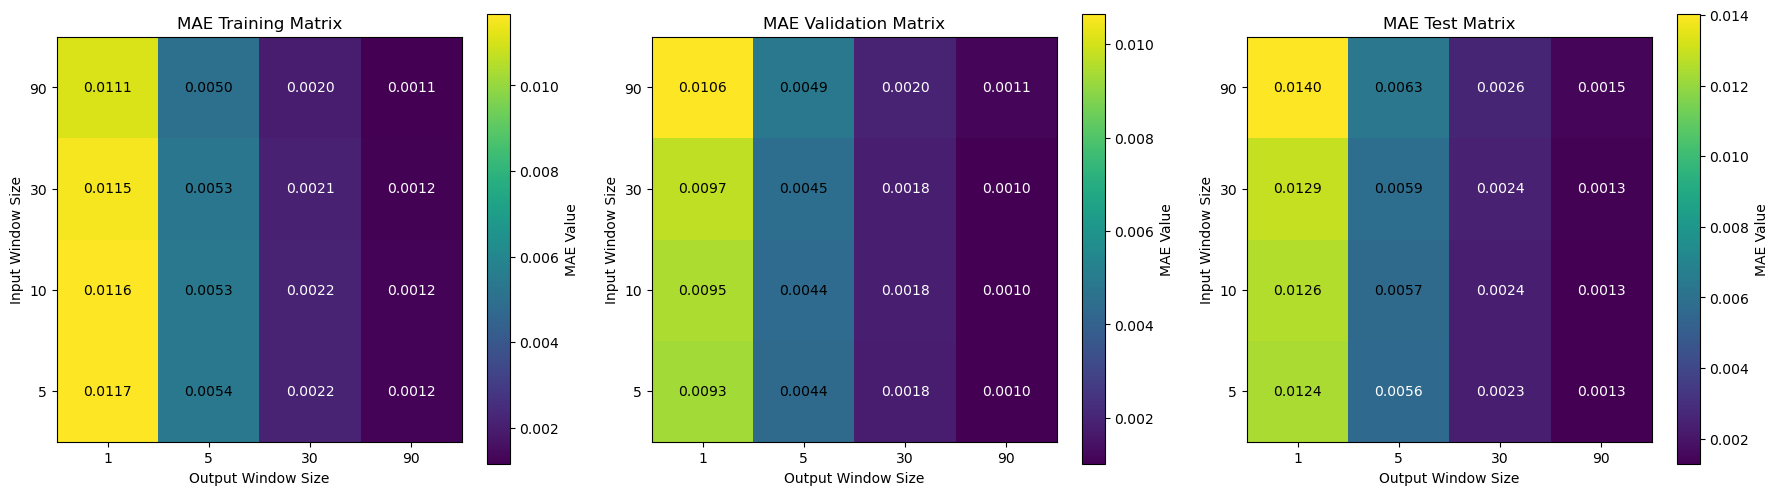

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [mae_train_matrix, mae_val_matrix, mae_test_matrix]
titles = ['MAE Training Matrix', 'MAE Validation Matrix', 'MAE Test Matrix']

for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', origin='lower')
    
    ax.set_xlabel('Output Window Size')
    ax.set_ylabel('Input Window Size')
    ax.set_title(titles[i])
    
    ax.set_xticks(np.arange(len(output_window_sizes)))
    ax.set_xticklabels(output_window_sizes)
    
    ax.set_yticks(np.arange(len(input_window_sizes)))
    ax.set_yticklabels(input_window_sizes)

    for y in range(matrices[i].shape[0]):
        for x in range(matrices[i].shape[1]):
            value = matrices[i][y, x]
            ax.text(x, y, f"{value:.4f}",
                    ha='center', va='center',
                    color='black' if value > np.mean(matrices[i]) else 'white')
    
    fig.colorbar(im, ax=ax, label='MAE Value')

plt.tight_layout()
plt.show()

## 3. Entrenamiento de modelos de Deep Learning

### 3.1 Modelos de capas densas (NN)

In [19]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from keras import regularizers

In [ ]:
# DEFINICION DEL MODELO: orden correcto de capas

model_NN = Sequential()
# 1. PRIMERO: Aplanar los datos 3D (ventana 10, 23 activos) a 2D
model_NN.add(Flatten(input_shape=(X_train_seq_final.shape[1], X_train_seq_final.shape[2])))
#model.add(Flatten(input_shape=(X_train_seq_final.shape[1]*X_train_seq_final.shape[2])))
#model.add(Dropout(0.2))

# 2. Capas Densas con abstracción progresiva
model_NN.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
model_NN.add(Dropout(0.3))
model_NN.add(Dense(64, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model.add(Dropout(0.2))
model_NN.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN.add(Dense(y_train_seq.shape[1], activation='sigmoid'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# ENTRENAMIENTO CON DATOS CORRECTAMENTE PREPARADOS
# Reshape X_train_seq_final a 2D (compatible con el flujo del modelo)
#X_train_2d = X_train_seq_final.reshape(X_train_seq_final.shape[0], -1)
#X_test_2d = X_test_seq_final.reshape(X_test_seq_final.shape[0], -1)

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN = model_NN.fit(X_train_seq_final, y_train_seq, validation_split=0.25, epochs=200, batch_size=32)

Epoch 1/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0150 - val_loss: 1.5383e-04
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.9304e-05 - val_loss: 8.4769e-05
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8268e-05 - val_loss: 6.5871e-05
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4697e-05 - val_loss: 5.8300e-05
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3300e-05 - val_loss: 5.4321e-05
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2530e-05 - val_loss: 5.1901e-05
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.2108e-05 - val_loss: 5.0321e-05
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1887e-05 - val_loss: 4.9277e-05
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1637e-05 - val_loss: 4.8543e-05
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1451e-05 - val_loss: 4.8081e-05
Epoch 11/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

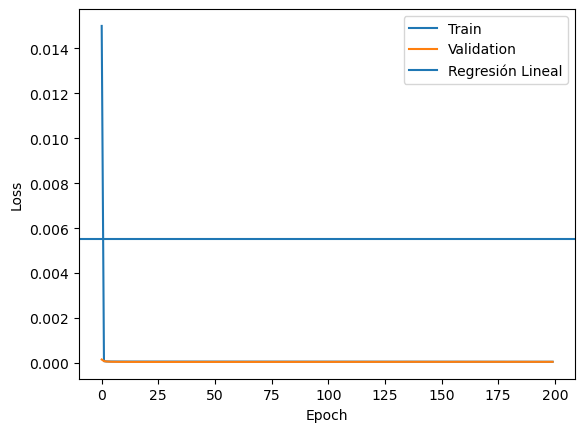

In [ ]:
plt.plot(hist_NN.history['loss'])
plt.plot(hist_NN.history['val_loss'])
plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.show()

### 3.2 Modelos de capas recurrentes (RNN)

In [16]:
model_RNN = Sequential()

model_RNN.add(LSTM(64, input_shape=(X_train_seq_final.shape[1], X_train_seq_final.shape[2]), dropout=0.2, recurrent_dropout=0.2, return_sequences = True))
model_RNN.add(LSTM(64, input_shape=(X_train_seq_final.shape[1], X_train_seq_final.shape[2]),dropout=0.2,recurrent_dropout=0.2))
model_RNN.add(Dense(y_train_seq.shape[1], activation='linear'))

model_RNN.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN = model_RNN.fit(X_train_seq_final, y_train_seq, validation_split=0.25, epochs=50, batch_size=32)

Epoch 1/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 4.6661e-04 - val_loss: 5.1696e-05
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 8.1098e-05 - val_loss: 4.7773e-05
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 6.8574e-05 - val_loss: 4.7969e-05
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 6.5796e-05 - val_loss: 4.7648e-05
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 6.4469e-05 - val_loss: 4.7724e-05
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 6.3755e-05 - val_loss: 4.7287e-05
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 6.3348e-05 - val_loss: 4.7581e-05
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 6.3034e-05 - val_loss: 4.8109e-05
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 6.2748e-05 - val_loss: 4.7869e-05
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 6.2365e-05 - val_loss: 4.7312e-05
Epoch 11/200
342/342 ━━━━━━━━━━━━━

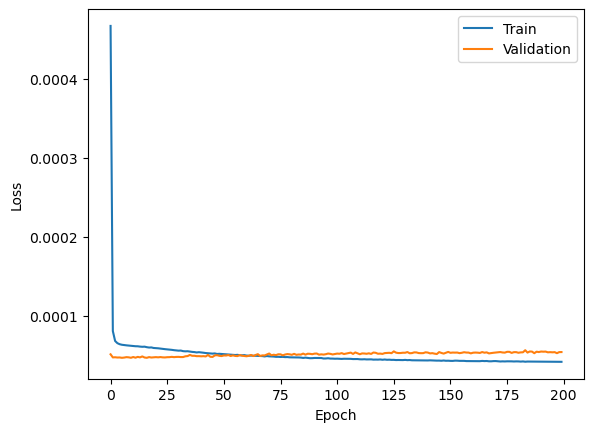

In [22]:
plt.plot(hist_RNN.history['loss'])
plt.plot(hist_RNN.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.show()

### 3.3 Modelos de capas convolucionales (CNN)

In [23]:
model_CNN = Sequential()

model_CNN.add(Convolution1D(filters=32, kernel_size=3, activation="relu", input_shape=(X_train_seq_final.shape[1], X_train_seq_final.shape[2])))
model_CNN.add(MaxPooling1D())
model_CNN.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
model_CNN.add(MaxPooling1D())
model_CNN.add(Flatten())
model_CNN.add(Dense(y_train_seq.shape[1], activation='linear'))

model_CNN.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN = model_CNN.fit(X_train_seq_final, y_train_seq, validation_split=0.25, epochs=60, batch_size=32)

Epoch 1/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0218 - val_loss: 2.4261e-04
Epoch 2/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.8563e-04 - val_loss: 1.0577e-04
Epoch 3/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 9.2313e-05 - val_loss: 8.5138e-05
Epoch 4/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.2138e-05 - val_loss: 7.7187e-05
Epoch 5/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.5462e-05 - val_loss: 7.2833e-05
Epoch 6/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.2924e-05 - val_loss: 7.0408e-05
Epoch 7/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.1886e-05 - val_loss: 6.8810e-05
Epoch 8/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.1443e-05 - val_loss: 6.7759e-05
Epoch 9/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.1258e-05 - val_loss: 6.7291e-05
Epoch 10/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.1186e-05 - val_loss: 6.6930e-05
Epoch 11/60
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.

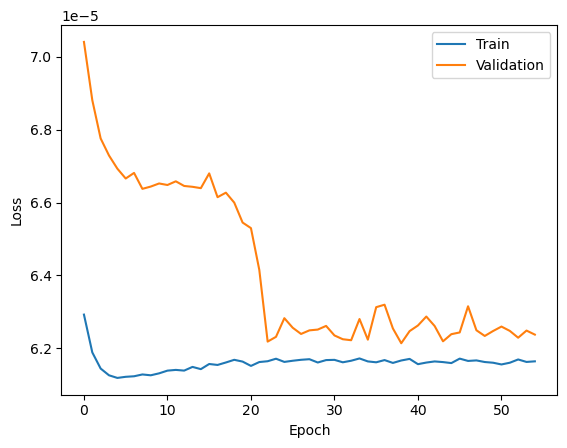

In [26]:
plt.plot(hist_CNN.history['loss'][5:])
plt.plot(hist_CNN.history['val_loss'][5:])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.show()